# Heracles

In [1]:
import jax.numpy as jnp
import jax.random as jrand
import matplotlib.pyplot as plt

from eleanor.jax.models import RNN, HeraclesCell, HeraclesParams

In [4]:
key = jrand.key(0)
kmodel, kstate, ksim = jrand.split(key, 3)

t = jnp.linspace(0, 1, 100).reshape(100, 1)
input = jnp.cos(8 * t)
input = 100e-12 * jnp.sign(input) * (input > 0.5)
felif = RNN(
    HeraclesCell(
        (1,),
        HeraclesParams(dt=1e-3, I_dsc=20e-12),
        n_steps=1,
        param_scale=1.0,
        return_states=True,
        key=kmodel,
    )
)
s_ms, v_ms, p_ms = felif(input, key=ksim)

t_us = jnp.linspace(0, 1, 100).reshape(100, 1)
input_us = jnp.cos(8 * t_us)
input_us = 100e-12 * jnp.sign(input_us) * (input_us > 0.5)
felif = RNN(
    HeraclesCell(
        (1,),
        HeraclesParams(dt=1e-3, I_dsc=20e-12),
        n_steps=1000,
        param_scale=1.0,
        return_states=True,
        key=kmodel,
    )
)
s_us, v_us, p_us = felif(input_us, key=ksim)

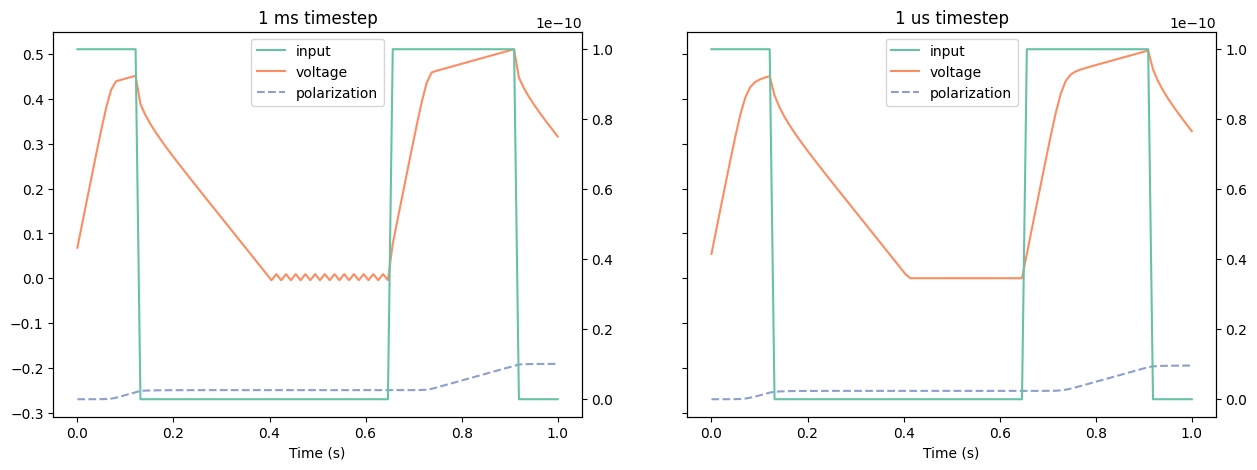

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
ax = axs[0].twinx()
lns1 = ax.plot(t, input, c="#66c2a5", label="input")
lns2 = axs[0].plot(t, v_ms, c="#fc8d62", label="voltage")
lns3 = axs[0].plot(t, p_ms, "--", c="#8da0cb", label="polarization")

# added these three lines
lns = lns1 + lns2 + lns3
labs = [label.get_label() for label in lns]
ax.legend(lns, labs, loc=0)
axs[0].set_xlabel("Time (s)")
axs[0].set_title("1 ms timestep")

ax = axs[1].twinx()
lns1 = ax.plot(t_us, input_us, c="#66c2a5", label="input")
lns2 = axs[1].plot(t_us, v_us, c="#fc8d62", label="voltage")
lns3 = axs[1].plot(t_us, p_us, "--", c="#8da0cb", label="polarization")

# added these three lines
lns = lns1 + lns2 + lns3
labs = [label.get_label() for label in lns]
ax.legend(lns, labs, loc=0)
axs[1].set_xlabel("Time (s)")
axs[1].set_title("1 us timestep")
plt.show()